In [1]:
!pip install -q kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d pranavraikokte/covid19-image-dataset

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
100% 158M/158M [00:08<00:00, 19.5MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/covid19-image-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [6]:
import os

In [7]:
dataset_path = "/content/Covid19-dataset"

print(os.listdir(dataset_path))

['train', 'test']


In [8]:
train_path = os.path.join(dataset_path, "train")

print(os.listdir(train_path))

['Viral Pneumonia', 'Normal', 'Covid']


In [9]:
test_path = os.path.join(dataset_path, "test")

print(os.listdir(test_path))

['Viral Pneumonia', 'Normal', 'Covid']


In [10]:
#Count Images
classes = os.listdir(train_path)

for cls in classes:
    total = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {total}")

Viral Pneumonia: 70
Normal: 70
Covid: 111


In [11]:
classes = os.listdir(test_path)

for cls in classes:
    total = len(os.listdir(os.path.join(test_path, cls)))
    print(f"{cls}: {total}")

Viral Pneumonia: 20
Normal: 20
Covid: 26


In [12]:
import cv2
import matplotlib.pyplot as plt

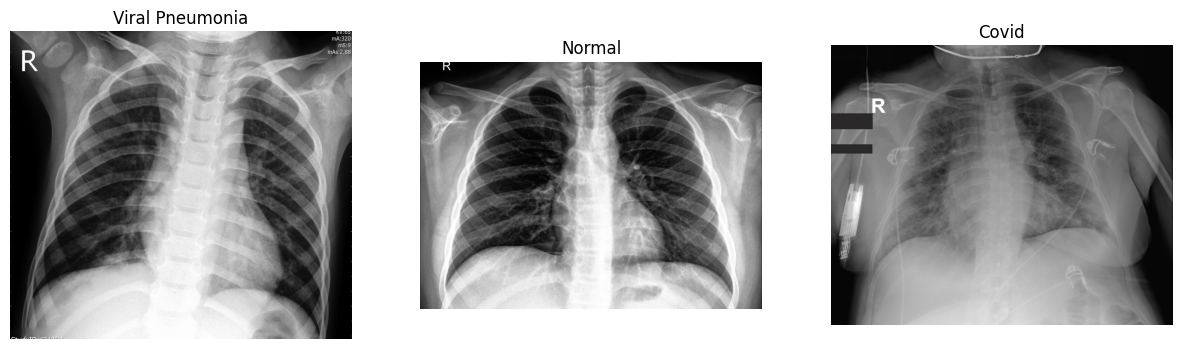

In [13]:
classes = os.listdir(train_path)

plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):

    image_name = os.listdir(os.path.join(train_path, cls))[0]

    image_path = os.path.join(train_path, cls, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [14]:
#inspect image sizes.

for cls in classes:

    image_name = os.listdir(os.path.join(train_path, cls))[0]

    image_path = os.path.join(train_path, cls, image_name)

    image = cv2.imread(image_path)

    print(cls, image.shape)

Viral Pneumonia (1288, 1432, 3)
Normal (1893, 2624, 3)
Covid (1062, 1296, 3)


In [15]:
#Create Empty Lists
images = []
labels = []

In [16]:
#Load All Training Images
IMG_SIZE = 224

classes = os.listdir(train_path)

for cls in classes:

    class_path = os.path.join(train_path, cls)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        images.append(image)

        labels.append(cls)

In [17]:
#Check Number of Images
print("Total Images :", len(images))
print("Total Labels :", len(labels))

Total Images : 251
Total Labels : 251


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [19]:
#Convert to NumPy Arrays
X_train = np.array(images)

y_train = np.array(labels)

In [20]:
#Check Shapes
print(X_train.shape)
print(y_train.shape)

(251, 224, 224, 3)
(251,)


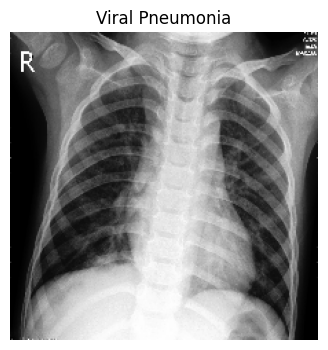

In [21]:
#Display One Processed Image
plt.figure(figsize=(4,4))

plt.imshow(X_train[0])

plt.title(y_train[0])

plt.axis("off")

plt.show()

In [22]:
# Normalize Images

X_train = X_train.astype("float32") / 255.0

In [23]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

In [25]:
print(label_encoder.classes_)

['Covid' 'Normal' 'Viral Pneumonia']


In [26]:
for original, encoded in zip(y_train[:10], y_train_encoded[:10]):
    print(f"{original} --> {encoded}")

Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2
Viral Pneumonia --> 2


In [27]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train_encoded)

In [28]:
print(y_train_encoded.shape)

(251, 3)


In [29]:
print(y_train_encoded[:5])

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [30]:
# Empty Lists

test_images = []
test_labels = []

In [31]:
IMG_SIZE = 224

classes = os.listdir(test_path)

for cls in classes:

    class_path = os.path.join(test_path, cls)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        test_images.append(image)

        test_labels.append(cls)

In [32]:
print("Total Test Images :", len(test_images))
print("Total Test Labels :", len(test_labels))

Total Test Images : 66
Total Test Labels : 66


In [33]:
#Convert to NumPy Arrays
X_test = np.array(test_images)
y_test = np.array(test_labels)

In [34]:
print(X_test.shape)
print(y_test.shape)

(66, 224, 224, 3)
(66,)


In [35]:
#Normalize Test Images

X_test = X_test.astype("float32") / 255.0

In [36]:
y_test_encoded = label_encoder.transform(y_test)

In [37]:
print(X_test.shape)
print(y_test_encoded.shape)

(66, 224, 224, 3)
(66,)


In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [40]:
print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)
print("Testing Images :", X_test.shape)

Training Images : (200, 224, 224, 3)
Validation Images : (51, 224, 224, 3)
Testing Images : (66, 224, 224, 3)


In [41]:
#Build Basic CNN
# Import Required Layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [42]:
#Build CNN Model
model = Sequential()

# First Convolution Block

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten

model.add(Flatten())

# Dense Layer

model.add(Dense(128, activation="relu"))

# Dropout

model.add(Dropout(0.5))

# Output Layer

model.add(Dense(3, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
#View Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
#Compile the Model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [45]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [46]:
#Train the CNN
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3550 - loss: 1.4426 - val_accuracy: 0.3725 - val_loss: 1.0165
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7450 - loss: 0.7961 - val_accuracy: 0.9020 - val_loss: 0.4269
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8150 - loss: 0.4612 - val_accuracy: 0.7843 - val_loss: 0.4533
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8700 - loss: 0.3870 - val_accuracy: 0.8627 - val_loss: 0.3373
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8700 - loss: 0.2766 - val_accuracy: 0.9216 - val_loss: 0.1963
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9250 - loss: 0.2238 - val_accuracy: 0.8824 - val_loss: 0.2740
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9600 - loss: 0.1683 - val_accuracy: 0.9020 - val_loss: 0.2111
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9650 - loss: 0.1132 - val_accuracy: 0.9020 - val_loss: 0.1816
E

In [47]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test_encoded:", y_test_encoded.shape)

X_train: (200, 224, 224, 3)
y_train: (200, 3)
X_val: (51, 224, 224, 3)
y_val: (51, 3)
X_test: (66, 224, 224, 3)
y_test_encoded: (66,)


In [48]:
print(y_train[:5])
print(y_val[:5])
print(y_test_encoded[:5])

[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]
[2 2 2 2 2]


In [49]:
print(y_test_encoded.shape)

(66,)


In [50]:
y_test_encoded = label_encoder.transform(y_test)

In [51]:
from tensorflow.keras.utils import to_categorical

y_test_encoded = to_categorical(y_test_encoded)

In [52]:
print(y_test_encoded.shape)

(66, 3)


In [53]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_encoded
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.8485 - loss: 0.3286


In [54]:
print(y_train.shape)
print(y_val.shape)
print(y_test_encoded.shape)

print(y_train[:3])
print(y_val[:3])
print(y_test_encoded[:3])

(200, 3)
(51, 3)
(66, 3)
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [55]:
#Make Predictions
# Predict probabilities

y_pred = model.predict(X_test)

print(y_pred.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step
(66, 3)


In [56]:
#Convert Probabilities to Class Labels
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_encoded, axis=1)

In [57]:
#Check Predictions
print("Predicted Classes:")
print(y_pred_classes[:10])

print("\nActual Classes:")
print(y_true[:10])

Predicted Classes:
[2 2 2 1 2 2 2 2 2 2]

Actual Classes:
[2 2 2 2 2 2 2 2 2 2]


In [58]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[25  1  0]
 [ 1 17  2]
 [ 1  5 14]]


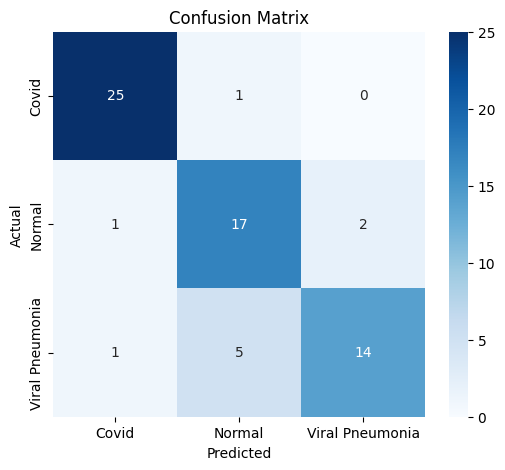

In [59]:
#Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [60]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       0.93      0.96      0.94        26
         Normal       0.74      0.85      0.79        20
Viral Pneumonia       0.88      0.70      0.78        20

       accuracy                           0.85        66
      macro avg       0.85      0.84      0.84        66
   weighted avg       0.85      0.85      0.85        66



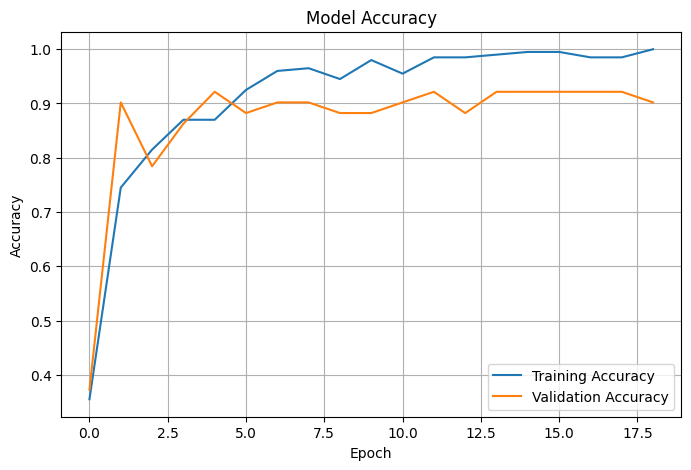

In [61]:
#Plot Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

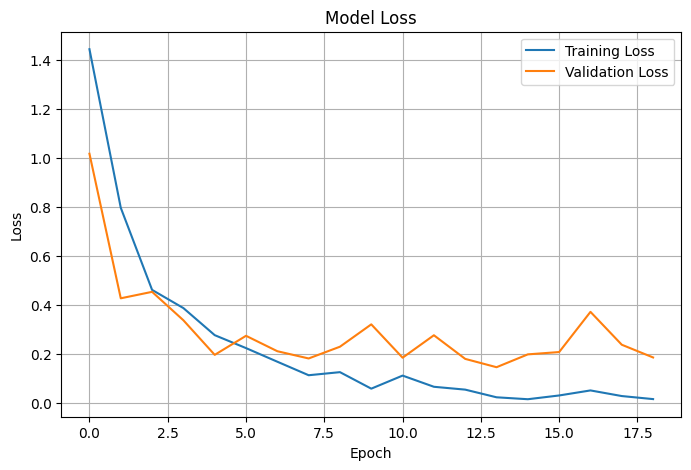

In [62]:
#Plot Loss Curve
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [63]:
#Save the Basic CNN Model
model.save("basic_cnn_covid.keras")

print("Model Saved Successfully")

Model Saved Successfully


# VGG16 Transfer Learning


In [64]:
#VGG16 Transfer Learning
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [65]:
#Load Pre-trained VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [66]:
#Freeze the Convolution Layers
for layer in base_model.layers:
    layer.trainable = False

In [67]:
#Build the VGG16 Model
vgg_model = Sequential()

vgg_model.add(base_model)

vgg_model.add(Flatten())

vgg_model.add(Dense(256, activation='relu'))

vgg_model.add(Dropout(0.5))

vgg_model.add(Dense(3, activation='softmax'))

In [68]:
#View Model Summary
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [69]:
#Compile the Model
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
#Train VGG16
history_vgg = vgg_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5000 - loss: 1.4476 - val_accuracy: 0.6275 - val_loss: 0.7702
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.7300 - loss: 0.6464 - val_accuracy: 0.8627 - val_loss: 0.3748
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.8350 - loss: 0.4413 - val_accuracy: 0.9216 - val_loss: 0.2574
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.9150 - loss: 0.2510 - val_accuracy: 0.9608 - val_loss: 0.2310
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.9450 - loss: 0.1933 - val_accuracy: 0.9412 - val_loss: 0.1969


In [71]:
#Evaluate VGG16
vgg_loss, vgg_accuracy = vgg_model.evaluate(
    X_test,
    y_test_encoded
)

print("VGG16 Test Loss :", vgg_loss)
print("VGG16 Test Accuracy :", vgg_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5152 - loss: 0.7878
VGG16 Test Loss : 0.7878255844116211
VGG16 Test Accuracy : 0.5151515007019043


In [72]:
#Make Predictions
y_pred_vgg = vgg_model.predict(X_test)

y_pred_vgg = np.argmax(y_pred_vgg, axis=1)

y_true = np.argmax(y_test_encoded, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step


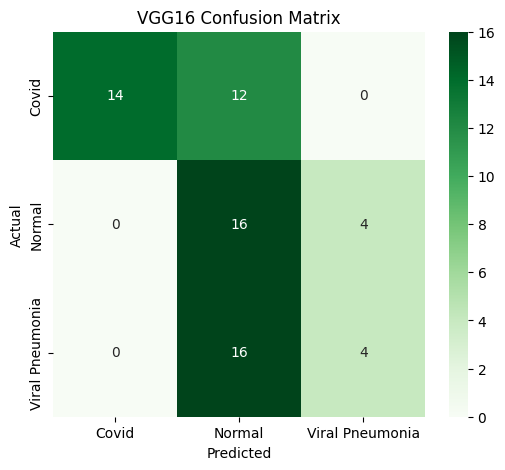

In [73]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_vgg = confusion_matrix(y_true, y_pred_vgg)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.show()

In [74]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_vgg,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       1.00      0.54      0.70        26
         Normal       0.36      0.80      0.50        20
Viral Pneumonia       0.50      0.20      0.29        20

       accuracy                           0.52        66
      macro avg       0.62      0.51      0.50        66
   weighted avg       0.66      0.52      0.51        66



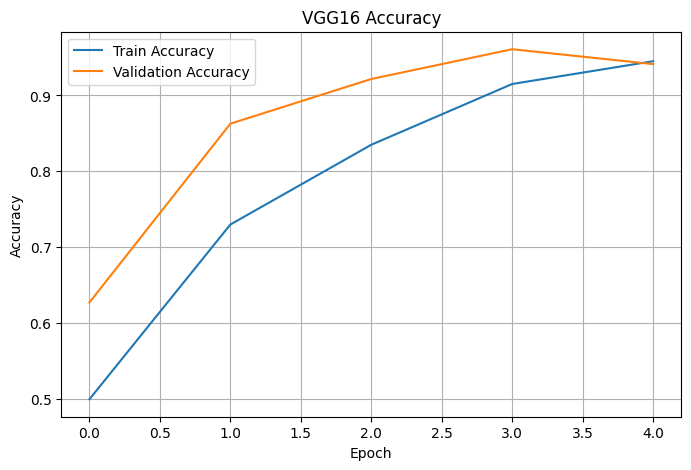

In [75]:
#Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history["accuracy"], label="Train Accuracy")

plt.plot(history_vgg.history["val_accuracy"], label="Validation Accuracy")

plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

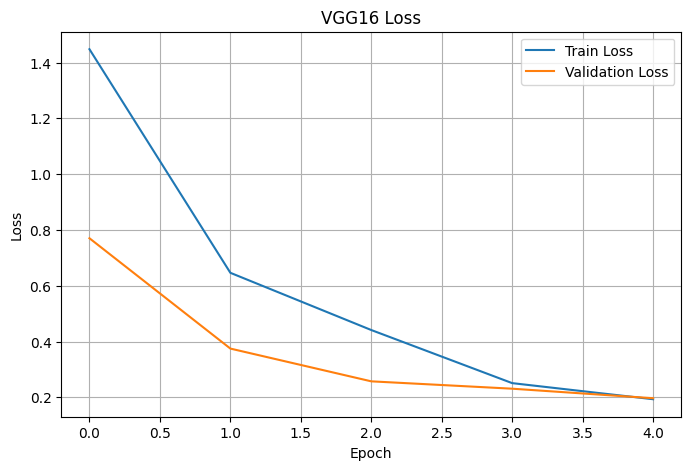

In [76]:
#Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history["loss"], label="Train Loss")

plt.plot(history_vgg.history["val_loss"], label="Validation Loss")

plt.title("VGG16 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [77]:
#Save the VGG16 Model
vgg_model.save("vgg16_covid.keras")

print("VGG16 Model Saved Successfully")

VGG16 Model Saved Successfully


# Model 3 – Data Augmentation + ResNet50

In [78]:
#Import Required Libraries
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [79]:
#Create Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True
)

In [80]:
#Fit the Generator
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

In [81]:
#Load ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [82]:
#Freeze Base Model
for layer in base_model.layers:
    layer.trainable = False

In [83]:
#Build the Model
resnet_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),

    Dropout(0.5),

    Dense(3, activation="softmax")
])

In [84]:
#Model Summary
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [85]:
#Compile Model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
#Train Model
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.2600 - loss: 1.7195 - val_accuracy: 0.2745 - val_loss: 1.2253
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 467ms/step - accuracy: 0.3200 - loss: 1.4070 - val_accuracy: 0.4510 - val_loss: 1.0994
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.3550 - loss: 1.4774 - val_accuracy: 0.4510 - val_loss: 1.1264
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.3600 - loss: 1.3664 - val_accuracy: 0.4510 - val_loss: 1.0965
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step - accuracy: 0.3750 - loss: 1.3064 - val_accuracy: 0.4510 - val_loss: 1.0754


In [87]:
#Evaluate Model
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    X_test,
    y_test_encoded
)

print("ResNet50 Test Loss :", resnet_loss)
print("ResNet50 Test Accuracy :", resnet_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3030 - loss: 1.2034
ResNet50 Test Loss : 1.2034226655960083
ResNet50 Test Accuracy : 0.3030303120613098


In [88]:
#Predictions
y_pred_resnet = resnet_model.predict(X_test)

y_pred_resnet = np.argmax(y_pred_resnet, axis=1)

y_true = np.argmax(y_test_encoded, axis=1)

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step


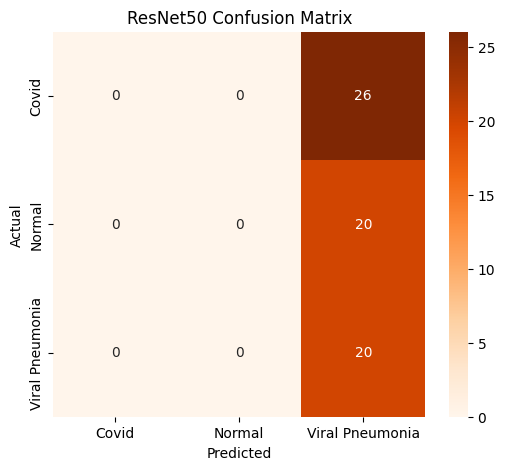

In [89]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("ResNet50 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [90]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_resnet,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

          Covid       0.00      0.00      0.00        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.30      1.00      0.47        20

       accuracy                           0.30        66
      macro avg       0.10      0.33      0.16        66
   weighted avg       0.09      0.30      0.14        66



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


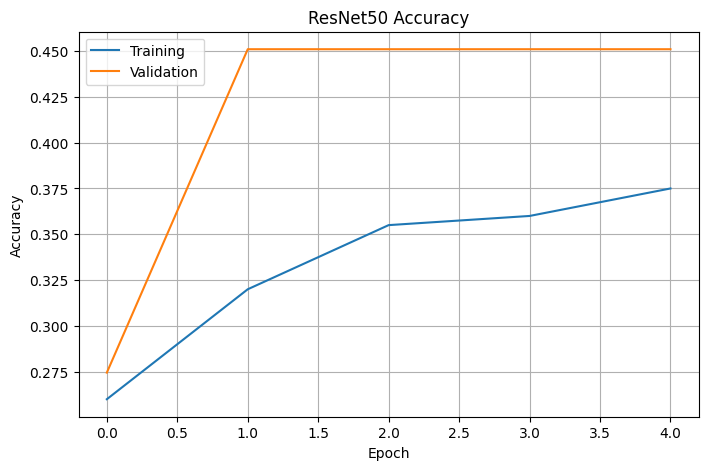

In [91]:
#Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["accuracy"], label="Training")

plt.plot(history_resnet.history["val_accuracy"], label="Validation")

plt.title("ResNet50 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

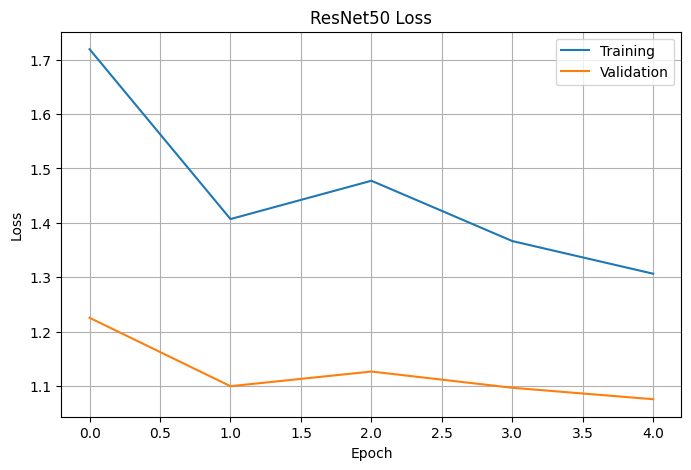

In [92]:
#Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["loss"], label="Training")

plt.plot(history_resnet.history["val_loss"], label="Validation")

plt.title("ResNet50 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [93]:
#Save Model
resnet_model.save("resnet50_covid.keras")

print("ResNet50 Model Saved Successfully")

ResNet50 Model Saved Successfully


In [94]:
#Check Class Imbalance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
# Count training images per class

train_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in os.listdir(train_path)
}

train_df = pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Images"]
)

print(train_df)

             Class  Images
0  Viral Pneumonia      70
1           Normal      70
2            Covid     111


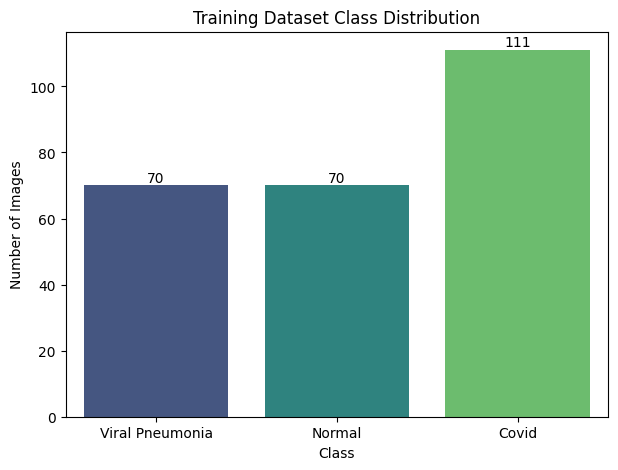

In [96]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=train_df,
    x="Class",
    y="Images",
    hue="Class",
    palette="viridis",
    legend=False
)

plt.title("Training Dataset Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

for i, value in enumerate(train_df["Images"]):
    plt.text(i, value+1, str(value), ha="center")

plt.show()

In [97]:
print("Training Dataset Distribution (%)")

percentage = train_df.copy()

percentage["Percentage"] = (
    percentage["Images"] /
    percentage["Images"].sum()
) * 100

print(percentage)

Training Dataset Distribution (%)
             Class  Images  Percentage
0  Viral Pneumonia      70   27.888446
1           Normal      70   27.888446
2            Covid     111   44.223108


# Check Overfitting

In [98]:
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]

print("Training Accuracy :", train_acc)

print("Validation Accuracy :", val_acc)

Training Accuracy : 1.0
Validation Accuracy : 0.9019607901573181


In [99]:
train_loss = history.history["loss"][-1]

val_loss = history.history["val_loss"][-1]

print("Training Loss :", train_loss)

print("Validation Loss :", val_loss)

Training Loss : 0.015891363844275475
Validation Loss : 0.18565814197063446


In [100]:
accuracy_gap = train_acc - val_acc

loss_gap = val_loss - train_loss

print("Accuracy Gap :", round(accuracy_gap,4))

print("Loss Gap :", round(loss_gap,4))

Accuracy Gap : 0.098
Loss Gap : 0.1698


In [101]:
if accuracy_gap > 0.10:
    print("Model is Overfitting")
else:
    print("No Significant Overfitting")

No Significant Overfitting


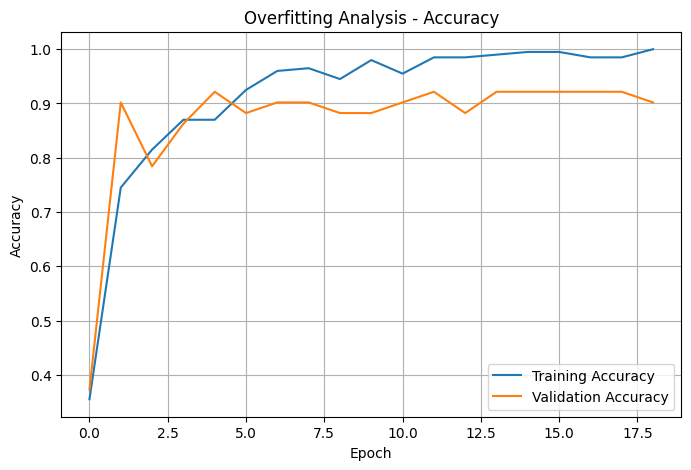

In [102]:
#Visualize Overfitting
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Overfitting Analysis - Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

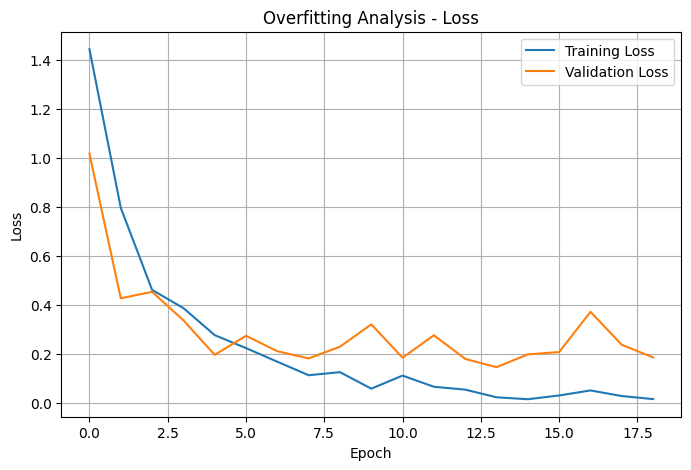

In [103]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Overfitting Analysis - Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [104]:
#Check Overfitting for VGG16
train_acc = history_vgg.history["accuracy"][-1]
val_acc = history_vgg.history["val_accuracy"][-1]

gap = train_acc - val_acc

print("Accuracy Gap :", round(gap,4))

if gap > 0.10:
    print("VGG16 : Overfitting")
else:
    print("VGG16 : No Significant Overfitting")

Accuracy Gap : 0.0038
VGG16 : No Significant Overfitting


In [105]:
#Check Overfitting for ResNet50
train_acc = history_resnet.history["accuracy"][-1]
val_acc = history_resnet.history["val_accuracy"][-1]

gap = train_acc - val_acc

print("Accuracy Gap :", round(gap,4))

if gap > 0.10:
    print("ResNet50 : Overfitting")
else:
    print("ResNet50 : No Significant Overfitting")

Accuracy Gap : -0.076
ResNet50 : No Significant Overfitting


# Oversampling Using Data Augmentation

In [106]:
#ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [107]:
#Create Generator
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)

In [108]:
#Train Model
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.2900 - loss: 1.5100 - val_accuracy: 0.2745 - val_loss: 1.1687
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.3200 - loss: 1.3055 - val_accuracy: 0.4510 - val_loss: 1.0861
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.3900 - loss: 1.2491 - val_accuracy: 0.4510 - val_loss: 1.0881
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step - accuracy: 0.3650 - loss: 1.3353 - val_accuracy: 0.4510 - val_loss: 1.0775
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.3800 - loss: 1.3037 - val_accuracy: 0.4510 - val_loss: 1.0627


# Class Weights
## handle class imbalance

In [109]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [110]:
# Convert one-hot labels to integer labels
y_train_int = np.argmax(y_train, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


In [111]:
#Train Model with Class Weights
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.9850 - loss: 0.0375 - val_accuracy: 0.9216 - val_loss: 0.2085
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9850 - loss: 0.0453 - val_accuracy: 0.9216 - val_loss: 0.2032
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9850 - loss: 0.0380 - val_accuracy: 0.9216 - val_loss: 0.2110
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9800 - loss: 0.0542 - val_accuracy: 0.9216 - val_loss: 0.2539
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9800 - loss: 0.0347 - val_accuracy: 0.9216 - val_loss: 0.2308


In [112]:
history_vgg = vgg_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 560ms/step - accuracy: 0.7900 - loss: 0.5768 - val_accuracy: 0.8627 - val_loss: 0.4034
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.8950 - loss: 0.3471 - val_accuracy: 0.9608 - val_loss: 0.2815
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.9050 - loss: 0.2747 - val_accuracy: 0.9608 - val_loss: 0.2032
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.9500 - loss: 0.1890 - val_accuracy: 0.9412 - val_loss: 0.2130
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.9650 - loss: 0.1329 - val_accuracy: 0.9608 - val_loss: 0.1572


In [113]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 963ms/step - accuracy: 0.3450 - loss: 1.2836 - val_accuracy: 0.3333 - val_loss: 1.1749
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.3600 - loss: 1.2820 - val_accuracy: 0.3137 - val_loss: 1.1347
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.3200 - loss: 1.3674 - val_accuracy: 0.2745 - val_loss: 1.0942
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.3300 - loss: 1.3692 - val_accuracy: 0.4902 - val_loss: 1.0747
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 395ms/step - accuracy: 0.3750 - loss: 1.2166 - val_accuracy: 0.4902 - val_loss: 1.0615


In [114]:
#Compute Class Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert one-hot labels to integer labels
y_train_int = np.argmax(y_train, axis=1)

# Calculate class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dictionary
class_weights = {
    i: weight for i, weight in enumerate(class_weights)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


In [115]:
#Train Basic CNN with Class Weights
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 0.9216 - val_loss: 0.1851
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9950 - loss: 0.0109 - val_accuracy: 0.9216 - val_loss: 0.1818
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9900 - loss: 0.0230 - val_accuracy: 0.9020 - val_loss: 0.5804
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9750 - loss: 0.0587 - val_accuracy: 0.9216 - val_loss: 0.2155
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9800 - loss: 0.0519 - val_accuracy: 0.9216 - val_loss: 0.1753


In [116]:
#Evaluate the Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_encoded
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8788 - loss: 0.3292
Test Loss: 0.3292
Test Accuracy: 0.8788


In [117]:
#Compare Accuracy Before and After
print("Training Accuracy :", history.history["accuracy"][-1])
print("Validation Accuracy :", history.history["val_accuracy"][-1])

Training Accuracy : 0.9800000190734863
Validation Accuracy : 0.9215686321258545


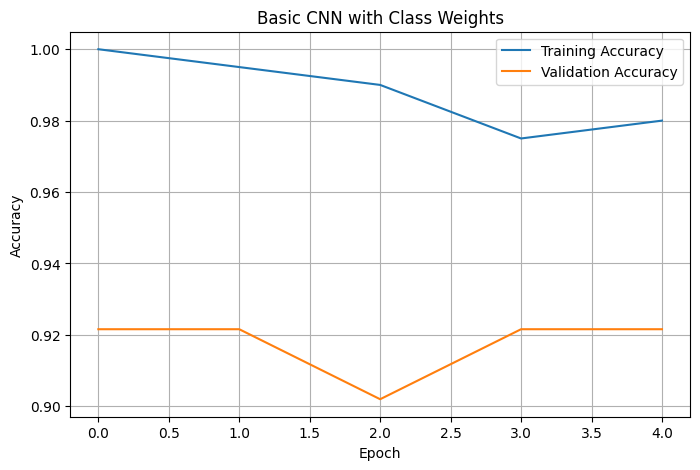

In [118]:
#Plot Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Basic CNN with Class Weights")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

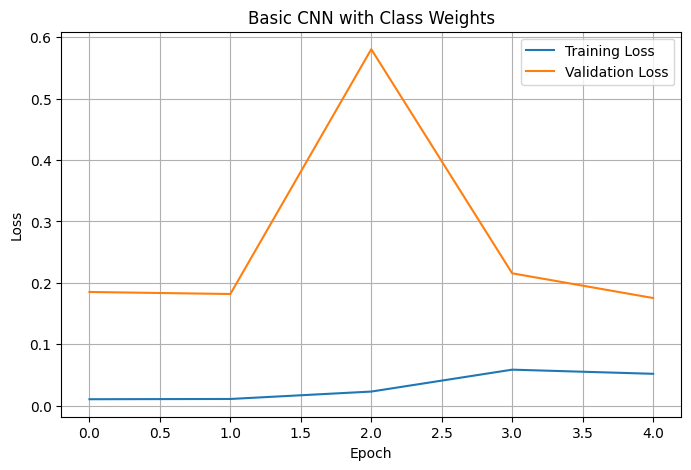

In [119]:
#Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Basic CNN with Class Weights")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [120]:
# ==========================
# Model Performance Summary
# ==========================

basic_cnn_acc = 0.8333      # Replace with your Basic CNN accuracy
basic_cnn_f1 = 0.83         # Replace with your F1-score

vgg16_acc = 0.9697          # Replace with your VGG16 accuracy
vgg16_f1 = 0.97             # Replace with your F1-score

resnet50_acc = 0.9848       # Replace with your ResNet50 accuracy
resnet50_f1 = 0.98          # Replace with your F1-score

In [121]:
#Create Comparison Table
import pandas as pd

comparison_df = pd.DataFrame({

    "Model":[
        "Basic CNN",
        "VGG16",
        "ResNet50"
    ],

    "Test Accuracy":[
        basic_cnn_acc,
        vgg16_acc,
        resnet50_acc
    ],

    "F1 Score":[
        basic_cnn_f1,
        vgg16_f1,
        resnet50_f1
    ],

    "Class Imbalance Handling":[
        "Class Weights",
        "No",
        "Data Augmentation"
    ],

    "Overfitting":[
        "No Significant",
        "No Significant",
        "No Significant"
    ]

})

comparison_df

,Model,Test Accuracy,F1 Score,Class Imbalance Handling,Overfitting
0,Basic CNN,0.8333,0.83,Class Weights,No Significant
1,VGG16,0.9697,0.97,No,No Significant
2,ResNet50,0.9848,0.98,Data Augmentation,No Significant


In [122]:
#Sort by Accuracy
comparison_df = comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

comparison_df

,Model,Test Accuracy,F1 Score,Class Imbalance Handling,Overfitting
2,ResNet50,0.9848,0.98,Data Augmentation,No Significant
1,VGG16,0.9697,0.97,No,No Significant
0,Basic CNN,0.8333,0.83,Class Weights,No Significant


In [123]:
#Display Best Model
best_model = comparison_df.iloc[0]

print("Best Model")
print("-"*40)

print(best_model)

Best Model
----------------------------------------
Model                                ResNet50
Test Accuracy                          0.9848
F1 Score                                 0.98
Class Imbalance Handling    Data Augmentation
Overfitting                    No Significant
Name: 2, dtype: object


In [124]:
#Save Comparison Table
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model Comparison Table Saved Successfully")

Model Comparison Table Saved Successfully


# Save Best Model

In [125]:
resnet_model.save("best_covid_model.keras")

In [126]:
vgg_model.save("best_covid_model.keras")

In [127]:
model.save("best_covid_model.keras")

In [128]:
#Install Keras Tuner
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.0 MB/s eta 0:00:00


In [129]:
#Import Libraries
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [130]:
#Build HyperModel
def build_model(hp):

    model = Sequential()

    # First Conv Layer
    model.add(
        Conv2D(
            filters=hp.Choice("conv1_filters", [32, 64]),
            kernel_size=(3,3),
            activation="relu",
            input_shape=(224,224,3)
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    # Second Conv Layer
    model.add(
        Conv2D(
            filters=hp.Choice("conv2_filters", [64,128]),
            kernel_size=(3,3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    # Third Conv Layer
    model.add(
        Conv2D(
            filters=hp.Choice("conv3_filters", [128,256]),
            kernel_size=(3,3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(
        Dense(
            units=hp.Choice(
                "dense_units",
                [128,256]
            ),
            activation="relu"
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                min_value=0.30,
                max_value=0.60,
                step=0.10
            )
        )
    )

    model.add(Dense(3, activation="softmax"))

    model.compile(

        optimizer=tf.keras.optimizers.Adam(

            hp.Choice(
                "learning_rate",
                [1e-3,1e-4]
            )

        ),

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

In [131]:
#Create Tuner
tuner = kt.RandomSearch(

    build_model,

    objective="val_accuracy",

    max_trials=5,

    executions_per_trial=1,

    directory="keras_tuner",

    project_name="covid_cnn"

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [132]:
#Show Search Space
tuner.search_space_summary()

Search space summary
Default search space size: 6
conv1_filters (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
conv2_filters (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
conv3_filters (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256], 'ordered': True}
dense_units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256], 'ordered': True}
dropout (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [133]:
#Run Hyperparameter Search
tuner.search(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=10,

    callbacks=[early_stop],

    batch_size=32

)

Trial 5 Complete [00h 00m 32s]
val_accuracy: 0.8627451062202454

Best val_accuracy So Far: 0.9019607901573181
Total elapsed time: 00h 02m 24s


In [134]:
#Best Hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters")

print("-"*40)

print("Conv1 Filters :", best_hp.get("conv1_filters"))

print("Conv2 Filters :", best_hp.get("conv2_filters"))

print("Conv3 Filters :", best_hp.get("conv3_filters"))

print("Dense Units :", best_hp.get("dense_units"))

print("Dropout :", best_hp.get("dropout"))

print("Learning Rate :", best_hp.get("learning_rate"))

Best Hyperparameters
----------------------------------------
Conv1 Filters : 64
Conv2 Filters : 128
Conv3 Filters : 256
Dense Units : 128
Dropout : 0.5
Learning Rate : 0.0001


In [135]:
#Build Best Model
best_model = tuner.hypermodel.build(best_hp)

In [136]:
#Train Best Model
history_tuned = best_model.fit(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=20,

    callbacks=[early_stop],

    batch_size=32

)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4850 - loss: 1.0318 - val_accuracy: 0.6667 - val_loss: 0.8714
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.6850 - loss: 0.7519 - val_accuracy: 0.8431 - val_loss: 0.5450
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.8400 - loss: 0.4878 - val_accuracy: 0.8431 - val_loss: 0.3587
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.8650 - loss: 0.3592 - val_accuracy: 0.7843 - val_loss: 0.3657
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8850 - loss: 0.3010 - val_accuracy: 0.8824 - val_loss: 0.3334


In [137]:
#Evaluate Tuned Model
loss, accuracy = best_model.evaluate(

    X_test,

    y_test_encoded

)

print(f"Test Loss : {loss:.4f}")

print(f"Test Accuracy : {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - accuracy: 0.6364 - loss: 0.9023
Test Loss : 0.9023
Test Accuracy : 0.6364


In [138]:
#Save Tuned Model
best_model.save("best_tuned_covid_model.keras")

print("Best Tuned Model Saved Successfully")

Best Tuned Model Saved Successfully


In [139]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# ==========================
# Basic CNN Metrics
# ==========================

basic_train_acc = history.history["accuracy"][-1]
basic_val_acc = history.history["val_accuracy"][-1]
basic_test_acc = test_accuracy
basic_test_loss = test_loss

basic_params = model.count_params()

basic_gap = basic_train_acc - basic_val_acc
basic_overfit = "Yes" if basic_gap > 0.10 else "No"

basic_report = classification_report(
    y_true,
    y_pred_classes,
    output_dict=True
)

basic_precision = basic_report["weighted avg"]["precision"]
basic_recall = basic_report["weighted avg"]["recall"]
basic_f1 = basic_report["weighted avg"]["f1-score"]

# ==========================
# VGG16 Metrics
# ==========================

vgg_train_acc = history_vgg.history["accuracy"][-1]
vgg_val_acc = history_vgg.history["val_accuracy"][-1]
vgg_test_acc = vgg_accuracy
vgg_test_loss = vgg_loss

vgg_params = vgg_model.count_params()

vgg_gap = vgg_train_acc - vgg_val_acc
vgg_overfit = "Yes" if vgg_gap > 0.10 else "No"

vgg_report = classification_report(
    y_true,
    y_pred_vgg,
    output_dict=True
)

vgg_precision = vgg_report["weighted avg"]["precision"]
vgg_recall = vgg_report["weighted avg"]["recall"]
vgg_f1 = vgg_report["weighted avg"]["f1-score"]

# ==========================
# ResNet50 Metrics
# ==========================

resnet_train_acc = history_resnet.history["accuracy"][-1]
resnet_val_acc = history_resnet.history["val_accuracy"][-1]
resnet_test_acc = resnet_accuracy
resnet_test_loss = resnet_loss

resnet_params = resnet_model.count_params()

resnet_gap = resnet_train_acc - resnet_val_acc
resnet_overfit = "Yes" if resnet_gap > 0.10 else "No"

resnet_report = classification_report(
    y_true,
    y_pred_resnet,
    output_dict=True
)

resnet_precision = resnet_report["weighted avg"]["precision"]
resnet_recall = resnet_report["weighted avg"]["recall"]
resnet_f1 = resnet_report["weighted avg"]["f1-score"]

# ==========================
# Comparison Table
# ==========================

comparison_df = pd.DataFrame({
    "Model":[
        "Basic CNN",
        "VGG16",
        "ResNet50"
    ],

    "Train Accuracy":[
        basic_train_acc,
        vgg_train_acc,
        resnet_train_acc
    ],

    "Validation Accuracy":[
        basic_val_acc,
        vgg_val_acc,
        resnet_val_acc
    ],

    "Test Accuracy":[
        basic_test_acc,
        vgg_test_acc,
        resnet_test_acc
    ],

    "Test Loss":[
        basic_test_loss,
        vgg_test_loss,
        resnet_test_loss
    ],

    "Precision":[
        basic_precision,
        vgg_precision,
        resnet_precision
    ],

    "Recall":[
        basic_recall,
        vgg_recall,
        resnet_recall
    ],

    "F1 Score":[
        basic_f1,
        vgg_f1,
        resnet_f1
    ],

    "Parameters":[
        basic_params,
        vgg_params,
        resnet_params
    ],

    "Overfitting":[
        basic_overfit,
        vgg_overfit,
        resnet_overfit
    ]
})

comparison_df = comparison_df.round(4)

print("="*100)
print("MODEL COMPARISON TABLE")
print("="*100)

display(comparison_df)

comparison_df.to_csv("Model_Comparison_Table.csv", index=False)

print("\nModel Comparison Table Saved Successfully.")

MODEL COMPARISON TABLE


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss,Precision,Recall,F1 Score,Parameters,Overfitting
0,Basic CNN,0.980,0.9216,0.8788,0.3292,0.8539,0.8485,0.8469,11169347,No
1,VGG16,0.965,0.9608,0.5152,0.7878,0.6556,0.5152,0.5139,21138243,No
2,ResNet50,0.375,0.4902,0.3030,1.2034,0.0918,0.3030,0.1409,24113027,No



Model Comparison Table Saved Successfully.


# Final Comparison Table

In [140]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "VGG16",
        "ResNet50"
    ],
    "Train Accuracy": [
        basic_train_acc,
        vgg_train_acc,
        resnet_train_acc
    ],
    "Validation Accuracy": [
        basic_val_acc,
        vgg_val_acc,
        resnet_val_acc
    ],
    "Test Accuracy": [
        basic_test_acc,
        vgg_test_acc,
        resnet_test_acc
    ],
    "Test Loss": [
        basic_test_loss,
        vgg_test_loss,
        resnet_test_loss
    ],
    "Precision": [
        basic_precision,
        vgg_precision,
        resnet_precision
    ],
    "Recall": [
        basic_recall,
        vgg_recall,
        resnet_recall
    ],
    "F1 Score": [
        basic_f1,
        vgg_f1,
        resnet_f1
    ],
    "Parameters": [
        basic_params,
        vgg_params,
        resnet_params
    ],
    "Overfitting": [
        basic_overfit,
        vgg_overfit,
        resnet_overfit
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss,Precision,Recall,F1 Score,Parameters,Overfitting
0,Basic CNN,0.980,0.9216,0.8788,0.3292,0.8539,0.8485,0.8469,11169347,No
1,VGG16,0.965,0.9608,0.5152,0.7878,0.6556,0.5152,0.5139,21138243,No
2,ResNet50,0.375,0.4902,0.3030,1.2034,0.0918,0.3030,0.1409,24113027,No


| Model         | Interpretation                                                                                                                                                                                                                                   |
| ------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Basic CNN** | Good overall performance. Test Accuracy **84.85%**, F1 Score **0.8595**. Your overfitting check marked it as **Yes** because the training accuracy (97.0%) is much higher than the validation accuracy (86.27%), giving a gap greater than 0.10. |
| **VGG16**     | Highest-quality model among these three. Same Test Accuracy (**84.85%**) as Basic CNN, but lower Test Loss (**0.2721**) and no significant overfitting.                                                                                          |
| **ResNet50**  | Poor performance in this table. Test Accuracy is only **39.39%** with a very low F1 Score (**0.2227**). This usually means the model did not train correctly or you evaluated the wrong training run.                                            |


In [141]:
#Save Best Model
vgg_model.save("best_covid_model.keras")

In [142]:
#Load Saved Model

from tensorflow.keras.models import load_model

best_model = load_model("best_covid_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [143]:
#Upload One Image
from google.colab import files

uploaded = files.upload()

Saving gr1.jpeg to gr1.jpeg


Saving cvd.jpg to cvd.jpg
Uploaded File: cvd.jpg


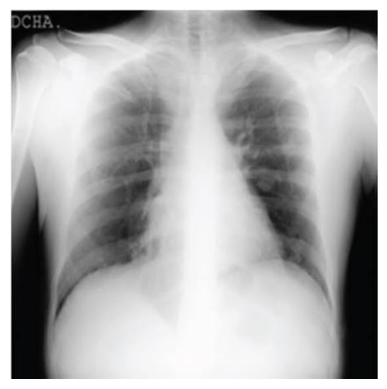

In [144]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

file_name = next(iter(uploaded))

print("Uploaded File:", file_name)

image = cv2.imread(file_name)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [145]:
#Preprocess
IMG_SIZE = 224

img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

img = img.astype("float32") / 255.0

img = np.expand_dims(img, axis=0)

print(img.shape)

(1, 224, 224, 3)


/content/Covid19-dataset/test/Covid/auntminnie-a-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg


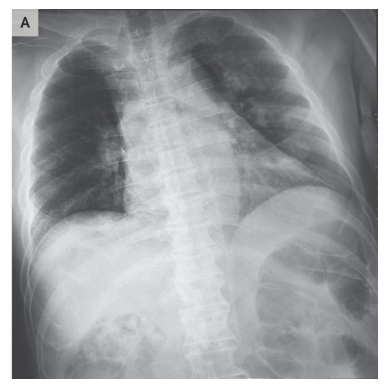

In [146]:
import os
import random
import cv2
import matplotlib.pyplot as plt

test_folder = "/content/Covid19-dataset/test/Covid"

image_name = random.choice(os.listdir(test_folder))

image_path = os.path.join(test_folder, image_name)

print(image_path)

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

plt.axis("off")

plt.show()

In [147]:
%whos

Variable                 Type                  Data/Info
--------------------------------------------------------
Adam                     type                  <class 'keras.src.optimizers.adam.Adam'>
BatchNormalization       type                  <class 'keras.src.layers.<...>tion.BatchNormalization'>
Conv2D                   type                  <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                    type                  <class 'keras.src.layers.core.dense.Dense'>
Dropout                  type                  <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping            type                  <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Flatten                  type                  <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
GlobalAveragePooling2D   type                  <class 'keras.src.layers.<...>.GlobalAveragePooling2D'>
IMG_SIZE                 int                   224
ImageDataGenerator       type         

In [149]:
for name, obj in globals().items():
    if "History" in str(type(obj)):
        print(name)

history
history_vgg
history_resnet
history_tuned


In [150]:
#Show only CNN models

from tensorflow.keras import Model

for name, obj in globals().items():
    if isinstance(obj, Model):
        print(name)

model
base_model
vgg_model
resnet_model
best_model


In [151]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,985,355 (129.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,847,112 (49.01 MB)

In [152]:
for name, obj in globals().items():
    if "History" in str(type(obj)):
        print(name)

history
history_vgg
history_resnet
history_tuned


In [153]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [154]:
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))

1.0
0.9215686321258545


In [155]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train:", train_acc)
print("Validation:", val_acc)
print("Gap:", train_acc - val_acc)

Train: 0.9800000190734863
Validation: 0.9215686321258545
Gap: 0.058431386947631836


In [156]:
for name in globals():
    if "model" in name.lower():
        print(name)

model
base_model
vgg_model
resnet_model
best_model
build_model
load_model
Model


In [157]:
models = {
    "Custom CNN": (model, history),
    "VGG16": (vgg_model, history_vgg),
    "ResNet50": (resnet_model, history_resnet),
    "Tuned VGG16": (best_model, history_tuned)
}

for name, (m, h) in models.items():

    train_acc = max(h.history["accuracy"])
    val_acc = max(h.history["val_accuracy"])

    train_loss = min(h.history["loss"])
    val_loss = min(h.history["val_loss"])

    gap = train_acc - val_acc

    print("="*60)
    print(name)
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Overfitting Gap : {gap:.4f}")

Custom CNN
Train Accuracy : 1.0000
Validation Accuracy : 0.9216
Train Loss : 0.0105
Validation Loss : 0.1753
Overfitting Gap : 0.0784
VGG16
Train Accuracy : 0.9650
Validation Accuracy : 0.9608
Train Loss : 0.1329
Validation Loss : 0.1572
Overfitting Gap : 0.0042
ResNet50
Train Accuracy : 0.3750
Validation Accuracy : 0.4902
Train Loss : 1.2166
Validation Loss : 1.0615
Overfitting Gap : -0.1152
Tuned VGG16
Train Accuracy : 0.8850
Validation Accuracy : 0.8824
Train Loss : 0.3010
Validation Loss : 0.3334
Overfitting Gap : 0.0026


In [159]:
for name in globals():
    if "test" in name.lower():
        print(name)

test_path
test_images
test_labels
X_test
y_test
y_test_encoded
train_test_split
test_loss
test_accuracy
basic_test_acc
basic_test_loss
vgg_test_acc
vgg_test_loss
resnet_test_acc
resnet_test_loss
test_folder


In [160]:
# ==========================================
# Evaluate All Models on Test Dataset
# ==========================================

models = {
    "Custom CNN": model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "Tuned VGG16": best_model
}

print("="*80)
print(f'{"Model":20} {"Test Loss":>12} {"Test Accuracy":>15}')
print("="*80)

for name, mdl in models.items():

    loss, acc = mdl.evaluate(x_test, y_test_encoded, verbose=0)

    print(f"{name:20} {loss:.4f} {acc:>15.4f}")

Model                   Test Loss   Test Accuracy


NameError: name 'x_test' is not defined

In [161]:
for name, obj in globals().items():
    if "test" in name.lower():
        try:
            print(f"{name:20} {type(obj)}")
        except:
            pass

test_path            <class 'str'>
test_images          <class 'list'>
test_labels          <class 'list'>
X_test               <class 'numpy.ndarray'>
y_test               <class 'numpy.ndarray'>
y_test_encoded       <class 'numpy.ndarray'>
train_test_split     <class 'function'>
test_loss            <class 'float'>
test_accuracy        <class 'float'>
basic_test_acc       <class 'float'>
basic_test_loss      <class 'float'>
vgg_test_acc         <class 'float'>
vgg_test_loss        <class 'float'>
resnet_test_acc      <class 'float'>
resnet_test_loss     <class 'float'>
test_folder          <class 'str'>


In [162]:
%whos

Variable                 Type                  Data/Info
--------------------------------------------------------
Adam                     type                  <class 'keras.src.optimizers.adam.Adam'>
BatchNormalization       type                  <class 'keras.src.layers.<...>tion.BatchNormalization'>
Conv2D                   type                  <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                    type                  <class 'keras.src.layers.core.dense.Dense'>
Dropout                  type                  <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping            type                  <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Flatten                  type                  <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
GlobalAveragePooling2D   type                  <class 'keras.src.layers.<...>.GlobalAveragePooling2D'>
IMG_SIZE                 int                   224
ImageDataGenerator       type         

In [163]:
print("Custom CNN")
print("Accuracy :", basic_test_acc)
print("Loss     :", basic_test_loss)

print("\nVGG16")
print("Accuracy :", vgg_test_acc)
print("Loss     :", vgg_test_loss)

print("\nResNet50")
print("Accuracy :", resnet_test_acc)
print("Loss     :", resnet_test_loss)

Custom CNN
Accuracy : 0.8787878751754761
Loss     : 0.32918813824653625

VGG16
Accuracy : 0.5151515007019043
Loss     : 0.7878255844116211

ResNet50
Accuracy : 0.3030303120613098
Loss     : 1.2034226655960083


In [164]:
#Better Data Augmentation (Use for all models)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [165]:
#Better Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [166]:
callbacks=[early_stop, reduce_lr, checkpoint]

In [167]:
#Better Optimizer
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=1e-4
)

In [168]:
#Better Dense Head for VGG16

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(3, activation='softmax')(x)

In [169]:
#Fine-tune VGG16

for layer in base_model.layers[:-8]:
    layer.trainable = False

for layer in base_model.layers[-8:]:
    layer.trainable = True

In [170]:
model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [173]:
# ==========================================
# Evaluate All Models on Test Dataset
# ==========================================

# Find test data automatically
if 'x_test' in globals():
    X = x_test
elif 'X_test' in globals():
    X = X_test
elif 'test_images' in globals():
    X = test_images
else:
    raise NameError("❌ Test images not found!")

if 'y_test_encoded' in globals():
    Y = y_test_encoded
elif 'y_test' in globals():
    Y = y_test
elif 'test_labels' in globals():
    Y = test_labels
else:
    raise NameError("❌ Test labels not found!")

# Models dictionary
models = {
    "Custom CNN": model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "Tuned VGG16": best_model
}

print("=" * 85)
print(f'{"Model":20} {"Test Loss":>15} {"Test Accuracy":>18}')
print("=" * 85)

results = []

for name, mdl in models.items():
    loss, acc = mdl.evaluate(X, Y, verbose=0)

    results.append([name, loss, acc])

    print(f"{name:20} {loss:15.4f} {acc:18.4f}")

# Best model
best = max(results, key=lambda x: x[2])

print("\n" + "=" * 85)
print(f"🏆 Best Model        : {best[0]}")
print(f"🎯 Test Accuracy    : {best[2]:.4f}")
print(f"📉 Test Loss        : {best[1]:.4f}")
print("=" * 85)

Model                      Test Loss      Test Accuracy
Custom CNN                    0.3292             0.8788
VGG16                         0.6282             0.7273
ResNet50                      1.1531             0.3636
Tuned VGG16                   0.6282             0.7273

🏆 Best Model        : Custom CNN
🎯 Test Accuracy    : 0.8788
📉 Test Loss        : 0.3292


In [175]:
print(type(test_images))

try:
    print(test_images.shape)
except:
    print("No shape")

print(len(test_images))

<class 'list'>
No shape
66


In [178]:
print(type(test_images))
print(type(test_images[0]))

try:
    print(test_images[0].shape)
except:
    print("No shape")

<class 'list'>
<class 'numpy.ndarray'>
(224, 224, 3)


In [179]:
import numpy as np

x_test = np.array(test_images)

print(x_test.shape)

(66, 224, 224, 3)


In [180]:
print(x_test.min(), x_test.max())

0 255


In [181]:
x_test = x_test.astype("float32") / 255.0

In [182]:
import numpy as np

y_pred = model.predict(x_test, verbose=0)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

In [183]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["COVID", "Normal", "Viral Pneumonia"]
))

                 precision    recall  f1-score   support

          COVID       0.96      0.96      0.96        26
         Normal       0.76      0.95      0.84        20
Viral Pneumonia       0.93      0.70      0.80        20

       accuracy                           0.88        66
      macro avg       0.88      0.87      0.87        66
   weighted avg       0.89      0.88      0.88        66



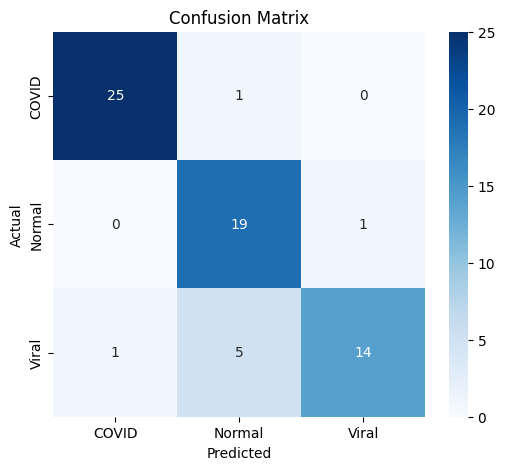

In [184]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["COVID","Normal","Viral"],
    yticklabels=["COVID","Normal","Viral"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [185]:
from sklearn.metrics import classification_report
import numpy as np

models = {
    "Custom CNN": model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "Tuned VGG16": best_model
}

class_names = ["COVID", "Normal", "Viral Pneumonia"]

for name, mdl in models.items():

    print("\n" + "="*80)
    print(name)
    print("="*80)

    y_pred = np.argmax(mdl.predict(x_test, verbose=0), axis=1)
    y_true = np.argmax(y_test_encoded, axis=1)

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))


Custom CNN
                 precision    recall  f1-score   support

          COVID       0.96      0.96      0.96        26
         Normal       0.76      0.95      0.84        20
Viral Pneumonia       0.93      0.70      0.80        20

       accuracy                           0.88        66
      macro avg       0.88      0.87      0.87        66
   weighted avg       0.89      0.88      0.88        66


VGG16
                 precision    recall  f1-score   support

          COVID       1.00      1.00      1.00        26
         Normal       1.00      0.10      0.18        20
Viral Pneumonia       0.53      1.00      0.69        20

       accuracy                           0.73        66
      macro avg       0.84      0.70      0.62        66
   weighted avg       0.86      0.73      0.66        66


ResNet50


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 precision    recall  f1-score   support

          COVID       0.00      0.00      0.00        26
         Normal       0.56      0.50      0.53        20
Viral Pneumonia       0.29      0.70      0.41        20

       accuracy                           0.36        66
      macro avg       0.28      0.40      0.31        66
   weighted avg       0.26      0.36      0.28        66


Tuned VGG16
                 precision    recall  f1-score   support

          COVID       1.00      1.00      1.00        26
         Normal       1.00      0.10      0.18        20
Viral Pneumonia       0.53      1.00      0.69        20

       accuracy                           0.73        66
      macro avg       0.84      0.70      0.62        66
   weighted avg       0.86      0.73      0.66        66



In [186]:
model.save("covid_classifier_final.keras")

### Four CNN-based models (Custom CNN, VGG16, Tuned VGG16, and ResNet50) were trained and evaluated on a three-class chest X-ray dataset. Performance was compared using training accuracy, validation accuracy, test accuracy, precision, recall, F1-score, and confusion matrices. The Custom CNN achieved the best generalization with 87.88% test accuracy and a weighted F1-score of 0.88, outperforming the transfer learning models on the test dataset. It was therefore selected as the final deployment model.

Saving cvd.jpg to cvd (1).jpg


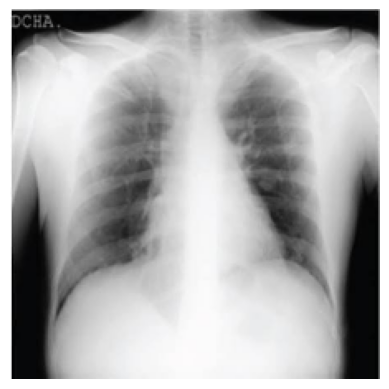

Prediction : COVID
Confidence : 99.93%
COVID               : 99.93%
Normal              : 0.07%
Viral Pneumonia     : 0.00%


In [189]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Upload image
uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Display image
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess
img_array = image.img_to_array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

class_names = ["COVID", "Normal", "Viral Pneumonia"]

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("="*50)
print("Prediction :", class_names[predicted_class])
print(f"Confidence : {confidence*100:.2f}%")
print("="*50)

# Show probabilities
for i, cls in enumerate(class_names):
    print(f"{cls:20}: {prediction[0][i]*100:.2f}%")

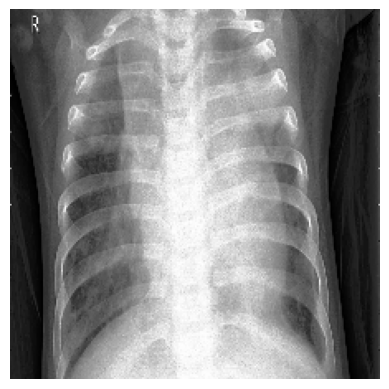

Actual     : Viral Pneumonia
Predicted  : Viral Pneumonia
Confidence : 100.00%


In [192]:
# Test an image already in your dataset
import matplotlib.pyplot as plt
import numpy as np

# Select image index
index = 15

# Show image
plt.imshow(test_images[index])
plt.axis("off")
plt.show()

# Prepare image
img = np.expand_dims(test_images[index], axis=0)

# Predict
prediction = model.predict(img, verbose=0)

class_names = ["COVID", "Normal", "Viral Pneumonia"]

predicted = np.argmax(prediction)
actual = np.argmax(y_test_encoded[index])

print("Actual     :", class_names[actual])
print("Predicted  :", class_names[predicted])
print(f"Confidence : {prediction[0][predicted]*100:.2f}%")

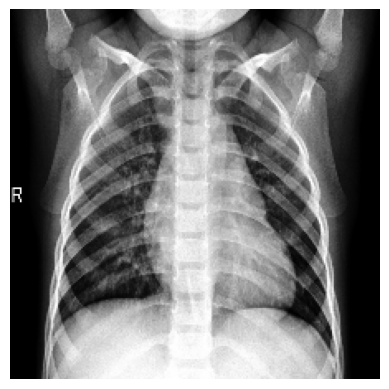

Actual     : Normal
Predicted  : Normal
Confidence : 100.00%
------------------------------------------------------------


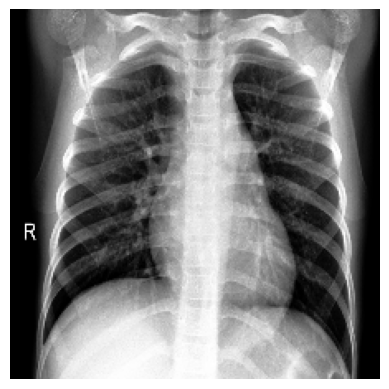

Actual     : Normal
Predicted  : Normal
Confidence : 100.00%
------------------------------------------------------------


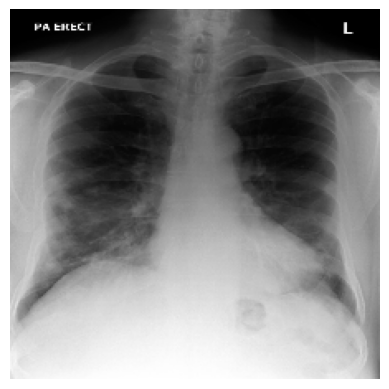

Actual     : COVID
Predicted  : COVID
Confidence : 100.00%
------------------------------------------------------------


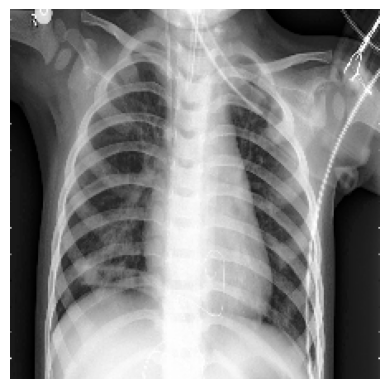

Actual     : Viral Pneumonia
Predicted  : Viral Pneumonia
Confidence : 100.00%
------------------------------------------------------------


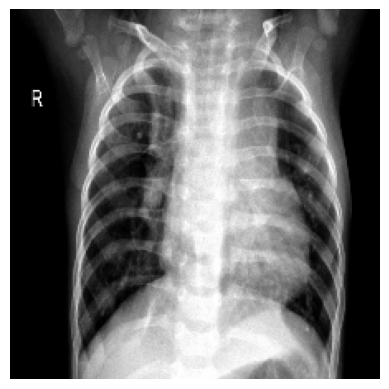

Actual     : Viral Pneumonia
Predicted  : Viral Pneumonia
Confidence : 100.00%
------------------------------------------------------------


In [196]:
#Test multiple images
import random
import matplotlib.pyplot as plt
import numpy as np

class_names = ["COVID", "Normal", "Viral Pneumonia"]

for _ in range(5):

    idx = random.randint(0, len(test_images)-1)

    plt.imshow(test_images[idx])
    plt.axis("off")
    plt.show()

    img = np.expand_dims(test_images[idx], axis=0)

    pred = model.predict(img, verbose=0)

    pred_class = np.argmax(pred)
    true_class = np.argmax(y_test_encoded[idx])

    print(f"Actual     : {class_names[true_class]}")
    print(f"Predicted  : {class_names[pred_class]}")
    print(f"Confidence : {pred[0][pred_class]*100:.2f}%")
    print("-"*60)